# EV price Prediction S6 E9

In [17]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
from pathlib import Path
from scipy import stats

In [37]:
import seaborn as sns

In [18]:
from sklearn.preprocessing import OneHotEncoder

In [19]:
train = pd.read_csv(r"C:\Advait\VS_Code\Data Analysis\Predicting Electric Vehicle Purchases Kaggle comp\train.csv")
test = pd.read_csv(r"C:\Advait\VS_Code\Data Analysis\Predicting Electric Vehicle Purchases Kaggle comp\test.csv")
sample = pd.read_csv(r"C:\Advait\VS_Code\Data Analysis\Predicting Electric Vehicle Purchases Kaggle comp\sample_submission.csv")

In [20]:
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [21]:
test.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


In [22]:
sample.head(100)

,id,Will_Buy_EV
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645
3,668668,0.174645
4,668669,0.174645
...,...,...
95,668760,0.174645
96,668761,0.174645
97,668762,0.174645
98,668763,0.174645


In [23]:
from rich.console import Console
console = Console()
from rich.pretty import Pretty
from rich.panel import Panel
from rich.table import Table

def show(text):
    console.print(Panel(Pretty(text)))


## EDA

In [24]:
def EDA(train, test, sample):
    datasets = {
        "train": train,
        "test": test,
        "sample": sample
    }
    MAX_CAT_VALUES = 10
    table = Table(title="Dataset Summary", show_header=True, header_style="bold magenta")
    table.add_column("Dataset", style="cyan", justify="left")
    table.add_column("Rows", style="green", justify="right")
    table.add_column("Columns", style="yellow", justify="right")

    for name, df in datasets.items():
        show(name)

        #Dataset Summary
        table.add_row(
            name.upper(),
            str(len(df)),
            str(len(df.columns))
        )

        # Missing Value
        missing = df.isna().sum()
        total_missing = missing.sum()

        if total_missing == 0:
            show(text=f"{name} dataset -> No Missing Value")
        else:
            show(text=f"{name} dataset with missing Values")
            missing_df = missing[missing > 0].reset_index()

            # Rename the column with ->
            
            missing_df.columns = ["Column", "Missing Count"]
            missing_df["%Missing"] = missing_df["Missing Count"] / len(df)
            show(missing_df)
            
    console.print(table)
    
    global all_desc, cat_desc 
    all_desc = {}
    cat_desc = {}
    print("Numerical Features")
    print("\n")
    for name, df in datasets.items():
        show(name)
        # Numerical Features
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        print("desc_df -> num_cols dict . describe() and skewness")
        if num_cols:
            # Generate describe stats and transpose (.T) to make features the rows
            desc_df = df[num_cols].describe().T
            
            desc_df['skew'] = df[num_cols].skew()
            
            # Save to the global dictionary
            all_desc[name] = desc_df

            # IRQ
            print("IRQ and Outliners")
            for col in num_cols:
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IRQ = Q3 - Q1
                lower_bound = Q1 - 1.5 * IRQ
                upper_bound = Q3 + 1.5 * IRQ
                outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
                outliers_rows = pd.DataFrame({
                    "column": [col],
                    "outliers": len(outliers),
                    "Lower Bound" : round(lower_bound, 2),
                    "Upper Bound" : round(upper_bound, 2)
                })
            show(outliers_rows)

        #Catagorical Features
        print("Categorical Features")
        cat_cols = df.select_dtypes(include=['object', 'str', 'string', 'category']).columns.tolist()

        if cat_cols:
            cat_info = pd.DataFrame({
                "Column": cat_cols,
                "Unique values": [df[col].nunique() for col in cat_cols]
            })
            cat_desc[name] = cat_info
            show("Value_counts")
            for col in cat_cols:
                vc = df[col].value_counts().head(MAX_CAT_VALUES)
                if len(vc) > MAX_CAT_VALUES:
                    show(df[col].nunique())
                else:
                    vc_df = pd.DataFrame({
                    'Value': vc.index,
                    'Count': vc.values,
                    '%': (vc.values / len(df) * 100).round(2)
                    })
                    show(vc_df)
                    




In [25]:
EDA(train, test, sample)

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 'train'                                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 'train dataset -> No Missing Value'                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 'test'                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 'test dataset -> No Missing Value'                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 'sample'                                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│     Value   Count      %                                                                                        │
│ 0     Low  259247  90.47                                                                                        │
│ 1  Medium   26295   9.18                                                                                        │
│ 2    High    1029   0.36                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 'sample'                                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

desc_df -> num_cols dict . describe() and skewness
IRQ and Outliners


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│         column  outliers  Lower Bound  Upper Bound                                                              │
│ 0  Will_Buy_EV         0         0.17         0.17                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Categorical Features


In [26]:
# View the Train statistics
display(all_desc["train"])

,count,mean,std,min,25%,50%,75%,max,skew
id,668665.0,334332.000000,193027.103211,0.0,167166.0,334332.0,501498.0,668664.0,0.000000
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0,-0.003786
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0,-0.013086
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7,-0.084589
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0,0.814497
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0,0.698730
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0,0.700188
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0,0.054283


In [27]:
# View the Train statistics
display(all_desc["test"])

,count,mean,std,min,25%,50%,75%,max,skew
id,286571.0,811950.000000,82726.066333,668665.0,740307.5,811950.0,883592.5,955235.0,-1.009869e-16
Age,286571.0,47.070824,12.864850,25.0,36.0,47.0,58.0,69.0,-7.360286e-03
Annual_Income_USD,286571.0,84799.508432,28626.851098,30000.0,67380.0,84926.0,102751.0,186936.0,-1.519478e-02
Daily_Commute_km,286571.0,32.159305,18.724436,5.0,17.2,33.6,47.3,103.9,-8.394514e-02
Number_of_Cars_Owned,286571.0,1.716095,0.731088,1.0,1.0,2.0,2.0,4.0,8.107312e-01
Charging_Stations_Near_Home,286571.0,4.950693,3.928626,0.0,2.0,4.0,7.0,14.0,7.017683e-01
Charging_Stations_Near_Work,286571.0,7.155626,5.186880,0.0,3.0,6.0,10.0,19.0,7.039175e-01
Environmental_Concern_Level,286571.0,2.934554,1.427541,1.0,2.0,3.0,4.0,5.0,5.373825e-02


In [28]:
# View the Train statistics
display(all_desc["sample"])

,count,mean,std,min,25%,50%,75%,max,skew
id,286571.0,811950.000000,82726.066333,668665.000000,740307.500000,811950.000000,883592.500000,955235.000000,-1.009869e-16
Will_Buy_EV,286571.0,0.174645,0.000000,0.174645,0.174645,0.174645,0.174645,0.174645,0.000000e+00


## Preprocessing

In [29]:
cat_Cols = test.select_dtypes(include=["str"]).columns.to_list()
cat_Cols

['Gender',
 'City_Type',
 'Current_Car_Type',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'Range_Anxiety_Level']

In [32]:
train.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV,Gender_Male,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_Yes,Subsidy_Available_Yes,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
0,66,92887.0,23.4,2,3,7,1.0,No,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,38,30000.0,5.0,1,2,2,4.0,No,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,26,94389.0,36.8,1,8,15,5.0,Yes,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,66,73580.0,23.7,2,6,9,3.0,No,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54,57898.0,50.8,1,2,3,3.0,No,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [30]:
global mapping
mapping = []
for col in cat_Cols:
    mapping.append({val: i for i, val in enumerate(train[col].unique())})
print(mapping)

[{'Male': 0, 'Female': 1, 'Other': 2}, {'Suburban': 0, 'Rural': 1, 'Urban': 2}, {'Sedan': 0, 'SUV': 1, 'Hatchback': 2, 'Truck': 3}, {'Yes': 0, 'No': 1}, {'No': 0, 'Yes': 1}, {'Low': 0, 'Medium': 1, 'High': 2}]


### OneHotEncoder

In [31]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first")
# Fit on train data and transform both train and test
train_encoded_array = encoder.fit_transform(train[cat_Cols])
test_encoded_array = encoder.transform(test[cat_Cols])

new_col_names = encoder.get_feature_names_out(cat_Cols)

# Convert the arrays back into DataFrames
train_encoded_df = pd.DataFrame(train_encoded_array, columns=new_col_names, index=train.index)
test_encoded_df = pd.DataFrame(test_encoded_array, columns=new_col_names, index=test.index)

# Drop the original categorical columns and ID, then join the new encoded columns
train = pd.concat([train.drop(columns=cat_Cols + ['id']), train_encoded_df], axis=1)
test = pd.concat([test.drop(columns=cat_Cols + ['id']), test_encoded_df], axis=1)

# Split X and y
X = train.drop(columns=['Will_Buy_EV'])
y = train['Will_Buy_EV']

In [40]:
train.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV,Gender_Male,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_Yes,Subsidy_Available_Yes,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
0,66,92887.0,23.4,2,3,7,1.0,No,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,38,30000.0,5.0,1,2,2,4.0,No,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,26,94389.0,36.8,1,8,15,5.0,Yes,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,66,73580.0,23.7,2,6,9,3.0,No,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54,57898.0,50.8,1,2,3,3.0,No,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [41]:
train['Will_Buy_EV'] = train['Will_Buy_EV'].str.lower().map({'yes': 1, 'no': 0})
train["Will_Buy_EV"]

0         0
1         0
2         1
3         0
4         0
         ..
668660    0
668661    0
668662    0
668663    0
668664    0
Name: Will_Buy_EV, Length: 668665, dtype: int64

In [35]:
y.head()

0     No
1     No
2    Yes
3     No
4     No
Name: Will_Buy_EV, dtype: str

<Axes: >

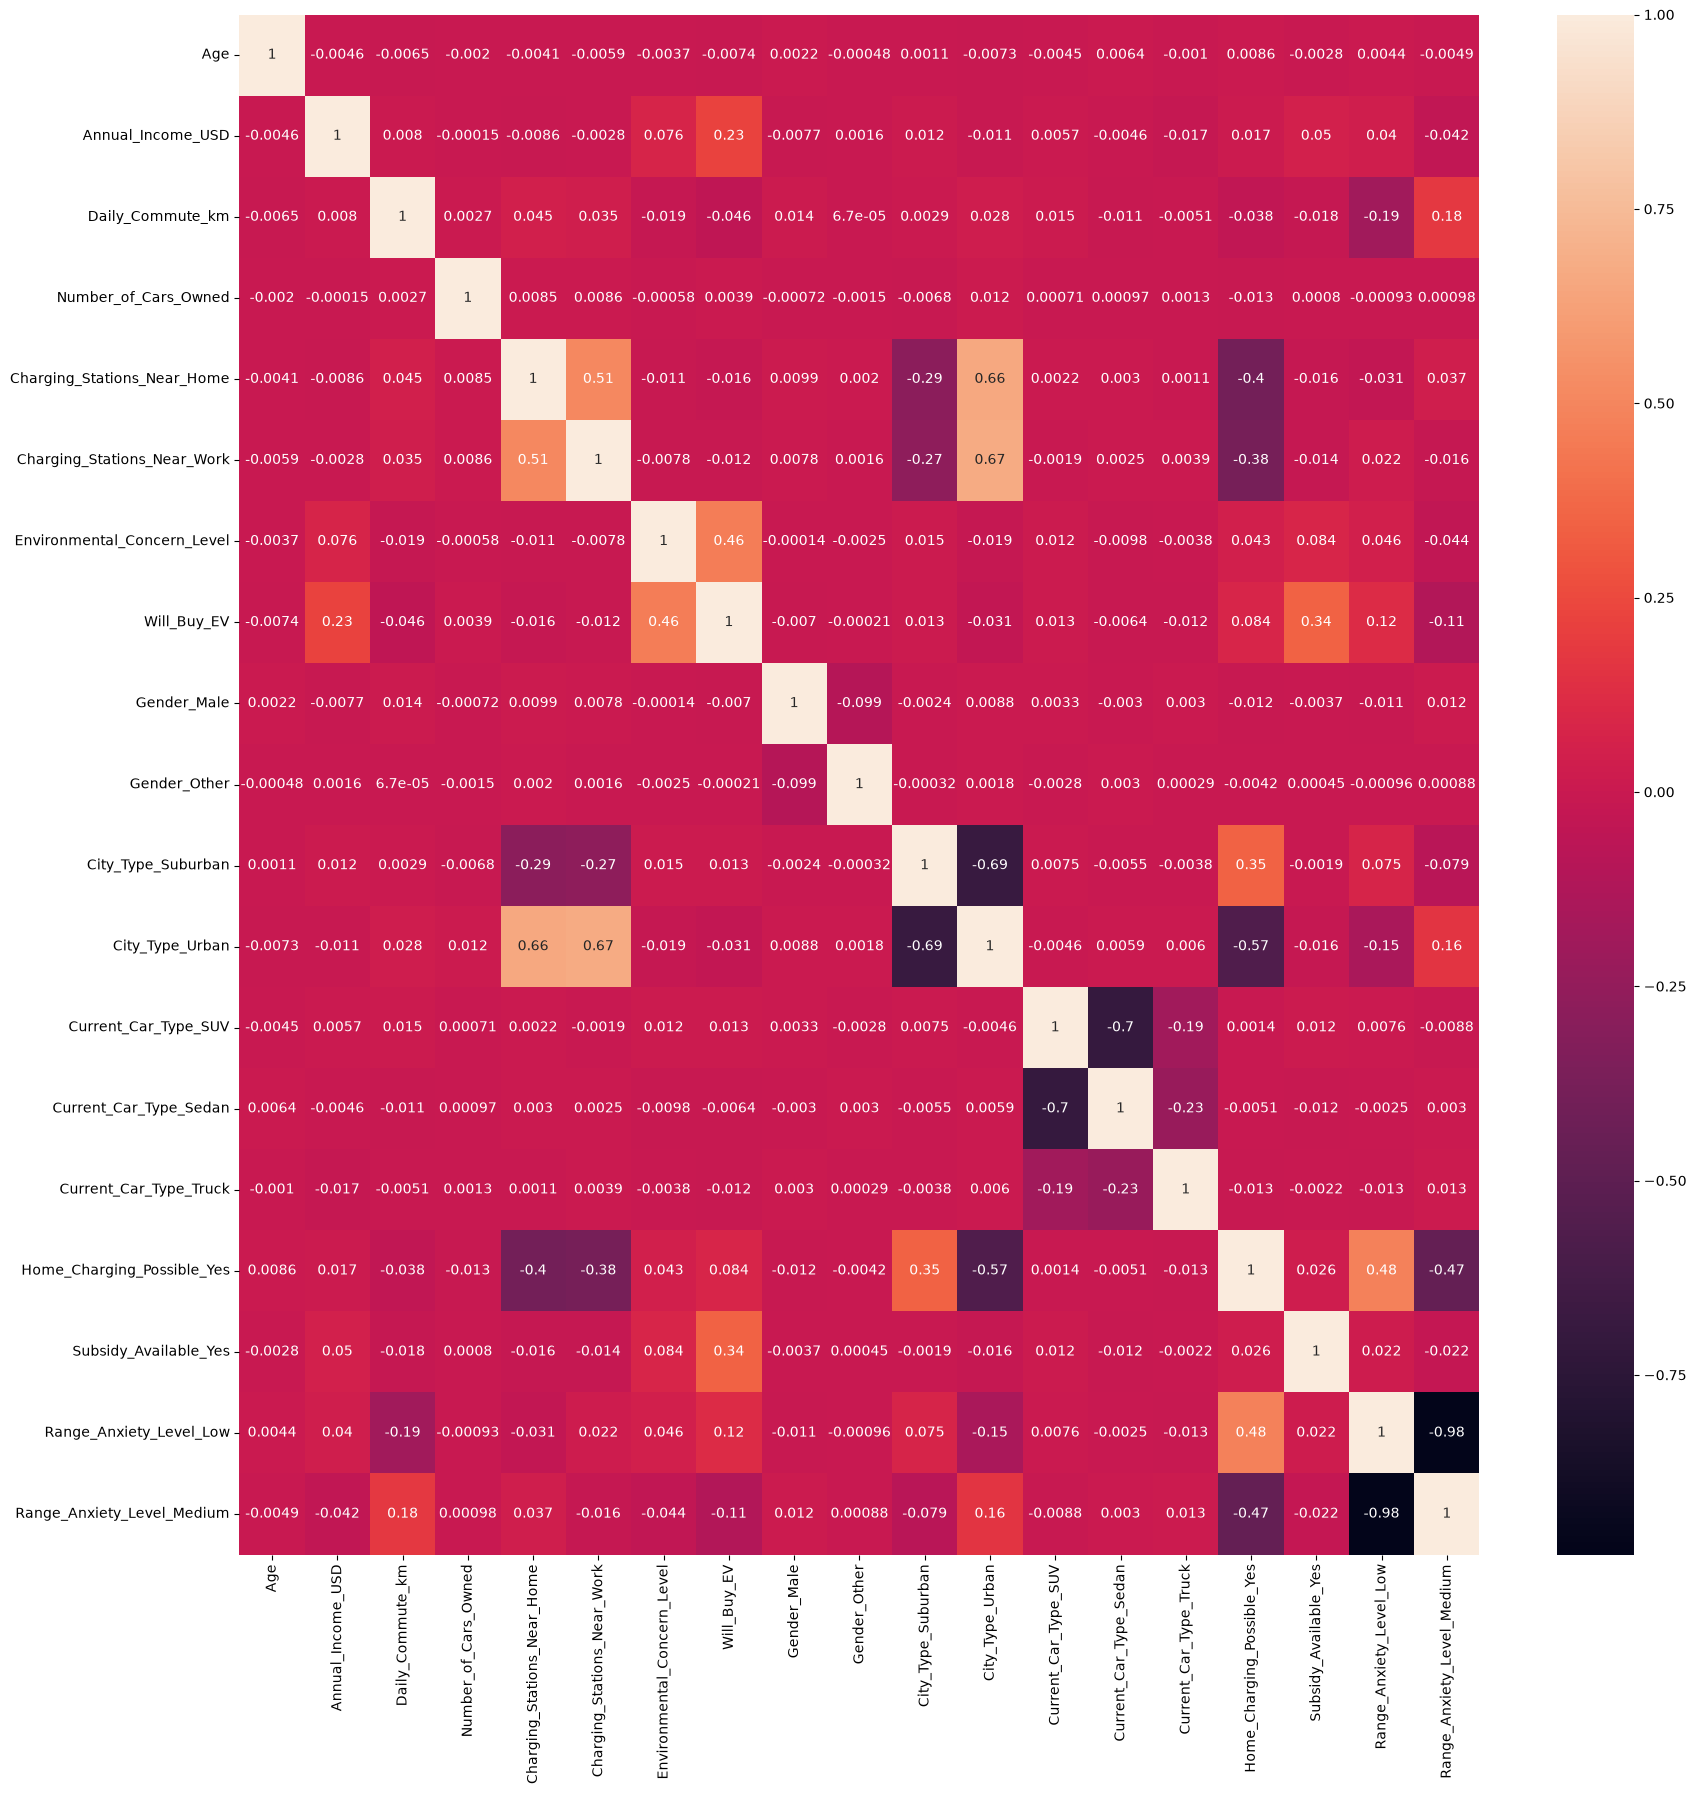

In [44]:
plt.figure(figsize=(20, 20))
sns.heatmap(train.corr(), annot=True)

## Feature Engineering

In [46]:
X.columns

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender_Male', 'Gender_Other',
       'City_Type_Suburban', 'City_Type_Urban', 'Current_Car_Type_SUV',
       'Current_Car_Type_Sedan', 'Current_Car_Type_Truck',
       'Home_Charging_Possible_Yes', 'Subsidy_Available_Yes',
       'Range_Anxiety_Level_Low', 'Range_Anxiety_Level_Medium'],
      dtype='str')

In [47]:
# +ve correlation

X["Income_subsidy_aval_yes"] = X["Annual_Income_USD"] * X["Subsidy_Available_Yes"]
test["Income_subsidy_aval_yes"] = test["Annual_Income_USD"] * test["Subsidy_Available_Yes"]

X["Income_Env_concern"] = X["Annual_Income_USD"] * X["Environmental_Concern_Level"]
test["Income_Env_concern"] = test["Annual_Income_USD"] * test["Environmental_Concern_Level"]

X["Env_subsidy_yes"] = X["Environmental_Concern_Level"] * X["Subsidy_Available_Yes"]
test["Env_subsidy_yes"] = test["Environmental_Concern_Level"] * test["Subsidy_Available_Yes"]

# -ve correlation


In [48]:
X["Income_subsidy_aval_yes"].corr()

TypeError: Series.corr() missing 1 required positional argument: 'other'